# Pipeline for model training

This notebook implements a complete training pipeline for geo-spatial models. It loads input data from .npz files, applies configurable sampling and dataset splitting strategies, and prepares training, validation, and test sets. The pipeline then trains a model using a simple convolutional neural network (CNN) chosen to ensure compatibility with small $3\times 3$ patches. User-defined parameters such as the sampling strategy and learning rate are set a `config.yaml` file. The notebook ends with a simple evalutation using test accuracy. Additional evaluation is done in the ´4_model_evaluation.ipynb´ notebook.

Expected input format for the data: .npz files ending in _data.npz. One per aquisition, not a combined one. The code will fetch these from the directory `TRAINING_DATA_DIR`.

Parameters to set in config file:
- sampling strategy
- split strategy
- transforms
- train/test/validation ratio
- channels
- patch size
- batch size
- epochs
- learning rate

### Import libraries and prepare directory paths

In [21]:
# TODO: Remove libraries that are not used

In [1]:
import importlib.metadata
import os
from collections.abc import Sequence
from functools import lru_cache
from pathlib import Path
from pprint import pprint
from typing import Any, Callable, ClassVar, Literal, Self

import lightning.pytorch as pl
import numpy as np
import terratorch
import torch
import torchgeo
import torchvision
import yaml
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler, random_split
import itertools

In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")
print(f"TorchGeo version: {torchgeo.__version__}")
print(f"TerraTorch version: {importlib.metadata.version('terratorch')}")

PyTorch version: 2.10.0+cu128
TorchVision version: 0.25.0+cu128
TorchGeo version: 0.9.0
TerraTorch version: 1.2.5


In [3]:
# Set user and directory variables
#USER = os.getenv("USER")
SCRATCH = os.getenv("SCRATCH")

DATA_ROOT = Path(f"{SCRATCH}/team1/data/")
TRAINING_DATA_DIR = DATA_ROOT / "training_data"

assert TRAINING_DATA_DIR.exists(), TRAINING_DATA_DIR

%matplotlib inline

### Data set and Corine classes

In [4]:
def _parse_npz_file(file_path):
    return np.load(file_path).values()


def get_class_distribution(dataset):
    distribution = {
        label.item(): count.item()
        for label, count in zip(*dataset.labels.unique(return_counts=True))
    }
    sorted_distribution = {
        k: v
        for k, v in sorted(distribution.items(), key=lambda item: item[1], reverse=True)
    }

    return sorted_distribution

In [5]:
CORINE_CLASSES = {
    # Artificial surfaces (1-11)
    1: "Continuous urban fabric",
    2: "Discontinuous urban fabric",
    3: "Industrial or commercial units",
    4: "Road and rail networks",
    5: "Port areas",
    6: "Airports",
    7: "Mineral extraction sites",
    8: "Dump sites",
    9: "Construction sites",
    10: "Green urban areas",
    11: "Sport and leisure facilities",
    # Agricultural areas (12-22)
    12: "Non-irrigated arable land",
    13: "Permanently irrigated land",
    14: "Rice fields",
    15: "Vineyards",
    16: "Fruit trees and berry plantations",
    17: "Olive groves",
    18: "Pastures",
    19: "Annual crops with permanent crops",
    20: "Complex cultivation patterns",
    21: "Agriculture with natural vegetation",
    22: "Agro-forestry areas",
    # Forest and semi-natural areas (23-34)
    23: "Broad-leaved forest",
    24: "Coniferous forest",
    25: "Mixed forest",
    26: "Natural grasslands",
    27: "Moors and heathland",
    28: "Sclerophyllous vegetation",
    29: "Transitional woodland-shrub",
    30: "Beaches, dunes, sands",
    31: "Bare rocks",
    32: "Sparsely vegetated areas",
    33: "Burnt areas",
    34: "Glaciers and perpetual snow",
    # Wetlands (35-39)
    35: "Inland marshes",
    36: "Peat bogs",
    37: "Salt marshes",
    38: "Salines",
    39: "Intertidal flats",
    # Water bodies (40-44)
    40: "Water courses",
    41: "Water bodies",
    42: "Coastal lagoons",
    43: "Estuaries",
    44: "Sea and ocean",
    48: "No data",
}

# Color mapping for visualization
CORINE_COLORS = {
    1: "#E6004D",
    2: "#FF0000",
    3: "#CC4DF2",
    4: "#CC0000",
    5: "#E6CCCC",
    6: "#E6CCE6",
    7: "#A600CC",
    8: "#A64DCC",
    9: "#FF4DFF",
    10: "#FFA6FF",
    11: "#FFE6FF",
    12: "#FFFFA8",
    13: "#FFFF00",
    14: "#E6E600",
    15: "#E68000",
    16: "#F2A64D",
    17: "#E6A600",
    18: "#E6E64D",
    19: "#FFE6A6",
    20: "#FFE64D",
    21: "#E6CC4D",
    22: "#F2CCA6",
    23: "#80FF00",
    24: "#00A600",
    25: "#4DFF00",
    26: "#CCF24D",
    27: "#A6FF80",
    28: "#A6E64D",
    29: "#A6F200",
    30: "#E6E6E6",
    31: "#CCCCCC",
    32: "#CCFFCC",
    33: "#000000",
    34: "#A6E6CC",
    35: "#A6A6FF",
    36: "#4D4DFF",
    37: "#CCCCFF",
    38: "#E6E6FF",
    39: "#A6A6E6",
    40: "#00CCF2",
    41: "#80F2E6",
    42: "#00FFA6",
    43: "#A6FFE6",
    44: "#E6F2FF",
}

print(f"✓ Defined {len(CORINE_CLASSES)} CORINE land cover classes")

✓ Defined 45 CORINE land cover classes


### Splitting the data intro training/test/validation

In [6]:
def get_split(
    sample_indices: torch.Tensor, ratios: list[float], generator: torch.Generator
) -> tuple[torch.Tensor, ...]:

    from math import floor

    if len(ratios) == 2:
        _, test_ratio = ratios
        val_ratio = None
    elif len(ratios) == 3:
        _, val_ratio, test_ratio = ratios
    else:
        raise ValueError(
            "Wrong number of ratios provided. Only 2 or 3 ratio values are admitted."
        )

    num_test = max(1, floor(test_ratio * len(sample_indices)))
    num_val = max(1, floor(val_ratio * len(sample_indices))) if val_ratio else 0
    num_train = len(sample_indices) - num_test - num_val

    assert num_train + num_val + num_test == len(sample_indices), (
        "Ratios do not ensure full coverage of samples."
    )

    random_indices = torch.randperm(len(sample_indices), generator=generator)
    slices = [
        slice(0, num_train),
        slice(num_train, num_train + num_val),
        slice(num_train + num_val, num_train + num_val + num_test),
    ]
    train_indices, val_indices, test_indices = [
        sample_indices[random_indices[s]] for s in slices
    ]

    if val_indices.numel() == 0:
        return train_indices, test_indices
    return train_indices, val_indices, test_indices

In [7]:
# TODO: Check if there are geospatially aware splitting methods of TerraTorch?
def make_splits_train_val_test(
    dataset: torch.Tensor,
    labels: torch.Tensor,
    train_frac: float = 0.9,
    val_frac: float = 0.05,
    test_frac: float = 0.05,
    seed: int = 42,
    stratify: bool = True,
) -> tuple[Subset, ...]:
    """
    Train/Val/Test split with optional stratification.

    Requirements:
      train_frac + val_frac + test_frac == 1.0
    """
    total = train_frac + val_frac + test_frac
    assert abs(total - 1.0) < 1e-6, "train_frac + val_frac + test_frac must be 1.0"

    ratios = [train_frac, val_frac, test_frac]
    generator = torch.Generator().manual_seed(seed)

    if not stratify:
        train_dataset, val_dataset, test_dataset = random_split(
            dataset, ratios, generator=generator
        )
        return train_dataset, val_dataset, test_dataset

    # labels = dataset.labels
    class_indices = [
        torch.argwhere(labels == label).flatten() for label in labels.unique()
    ]
    class_splits = [
        get_split(indices, ratios=ratios, generator=generator)
        for indices in class_indices
    ]
    subset_indices = map(torch.cat, zip(*class_splits))

    return tuple([Subset(dataset, index_set) for index_set in subset_indices])

### Configuration

In [8]:
# TODO: Modify the config file to fit the data (and motivate it)

In [9]:
with open(Path() / "config.yaml", mode="r", encoding="utf-8") as src:
    cfg = yaml.safe_load(src)

pprint(cfg)

{'data': {'sampling_strategy': 'weighted',
          'split_strategy': 'stratified',
          'test_ratio': 0.05,
          'train_ratio': 0.9,
          'transforms': {'train': None, 'val': None},
          'val_ratio': 0.05},
 'model': {'in_channels': 4, 'patch_size': 3},
 'training': {'batch_size': 32, 'epochs': 1, 'lr': 1e-05}}


### Preparing the data

This class consists of methods for loading, combining and splitting data. Additionally, it identifies classes and drops (blacklists) classes that are rare in the data.

In [10]:
class CorineDatasetProcessor:
    """
    Custom Dataset for remote sensing data.

    Parameters:
    -----------
    data : torch.Tensor
        Feature data (n_samples, n_channels, patch_height, patch_width)
    labels : torch.Tensor
        Target labels (n_samples,)
    """

    corine_classes = CORINE_CLASSES

    @classmethod
    def from_npz(cls, folder_path):
        file_paths = folder_path.glob("*_data.npz")
        data, labels = map(np.concatenate, zip(*map(_parse_npz_file, file_paths)))

        return cls(torch.tensor(data), torch.tensor(labels))

    def __init__(self, data: torch.Tensor, labels: torch.Tensor):

        self.data = data
        self.original_labels = labels

        self.unique_original_labels = self.original_labels.unique()
        self.label_mapping = {
            lbl.item(): i for i, lbl in enumerate(self.unique_original_labels)
        }
        self.reverse_label_mapping = {
            i: lbl.item() for i, lbl in enumerate(self.unique_original_labels)
        }
        self.labels = torch.tensor(
            [self.label_mapping[lbl.item()] for lbl in labels]
        ).type_as(self.original_labels)
        self.unique_labels = self.labels.unique()

        self.class_names = {
            self.label_mapping[lbl.item()]: self.corine_classes[lbl.item()]
            for lbl in self.unique_original_labels
        }

    def drop_labels(self, blacklist: list[int], use_original: bool = True) -> Self:
        if use_original:
            blacklist = [self.reverse_label_mapping[label] for label in blacklist]
        blacklist = torch.tensor(blacklist).type_as(self.original_labels)
        keep_indices = ~torch.isin(self.original_labels, blacklist)
        filtered_data, filtered_orig_labels = (
            self.data[keep_indices],
            self.original_labels[keep_indices],
        )

        return type(self)(filtered_data, filtered_orig_labels)

    def _format_class_name(self, class_name: str) -> str:
        replacements = ((" ", "_"), ("-", "_"))

        for old, new in replacements:
            class_name = class_name.strip().replace(old, new)

        return class_name.lower()

    # TODO: make root folder a ContextVar
    def create_class_folder(self, root: Path, class_name: str) -> Path:

        folder_name = self._format_class_name(class_name)
        folder_path = root / folder_name
        folder_path.mkdir(parents=True, exist_ok=True) # Avoids crash of folder already exist (but still redoes the split)

        return folder_path.resolve()

    def create_imagefolder_structure(
        self, root: os.PathLike | Path, split: str
    ) -> dict[int, Path]:
        split_folder = Path(root) / split
        class_folder_router = {
            idx: self.create_class_folder(split_folder, class_name)
            for idx, class_name in self.class_names.items()
        }

        return class_folder_router

    def save_split(self, split_indices: Subset, root: os.PathLike | Path, split: str):
        folder_router = self.create_imagefolder_structure(root, split)
        data, labels = self.data[split_indices], self.labels[split_indices]
    
        assert len(data) == len(labels) and len(data) > 0
    
        n = len(data)
        skipped = 0
    
        for i, (idx, patch, label) in enumerate(zip(split_indices, data, labels), 1):
            filepath = folder_router[label.item()] / f"{idx}.npy"
    
            if filepath.exists():
                skipped += 1
            else:
                np.save(filepath, patch.numpy())
    
            if i % 10000 == 0 or i == n:
                print(f"{split}: {i}/{n} processed (skipped {skipped})")
    

    def make_splits(self, root: os.PathLike | Path, **kwargs):
        stratify = kwargs.get("split_strategy", "random") == "stratified"
        print(f"Creating splits (stratify={stratify})...")


        subsets = make_splits_train_val_test(
            self.data,
            self.labels,
            train_frac=kwargs["train_ratio"],
            val_frac=kwargs["val_ratio"],
            test_frac=kwargs["test_ratio"],
            stratify=stratify,
        )

        print("Splits created.")
        print(f"Train: {len(subsets[0])}, Val: {len(subsets[1])}, Test: {len(subsets[2])}")

        
        # Save split
        for subset, split in zip(subsets, ["train", "val", "test"]):
            print(f"Saving {split} split with {len(subset)} samples...")
            self.save_split(subset.indices, root, split)
            print(f"Finished saving {split} split.")

        return subsets


In [11]:
processor = CorineDatasetProcessor.from_npz(TRAINING_DATA_DIR)

### Information about classes and their distribution

In [12]:
processor.class_names

{0: 'Discontinuous urban fabric',
 1: 'Non-irrigated arable land',
 2: 'Agriculture with natural vegetation',
 3: 'Coniferous forest',
 4: 'Mixed forest',
 5: 'Transitional woodland-shrub',
 6: 'Peat bogs',
 7: 'Water bodies'}

In [13]:
class_distribution = get_class_distribution(processor)

print("Labels distribution")
print(class_distribution)

print("\nLabel distribution (%)")
total = sum(class_distribution.values())

class_percentages = {
    cls: count / total * 100
    for cls, count in class_distribution.items()
}

print({cls: f"{pct:.2f}%" for cls, pct in class_percentages.items()})

print("\nMapping")
print(processor.label_mapping)

Labels distribution
{3: 137216, 5: 15667, 1: 15368, 4: 9883, 7: 9165, 6: 5505, 0: 3865, 2: 3331}

Label distribution (%)
{3: '68.61%', 5: '7.83%', 1: '7.68%', 4: '4.94%', 7: '4.58%', 6: '2.75%', 0: '1.93%', 2: '1.67%'}

Mapping
{2: 0, 12: 1, 21: 2, 24: 3, 25: 4, 29: 5, 36: 6, 41: 7}


In [14]:
# Blacklists classes that have less than 10 occurances in the data
blacklist = [idx for idx in class_distribution if class_distribution[idx] < 10]
print(blacklist)

[]


Since no classes are blacklisted, there is no need to use `processor = processor.drop_labels(blacklist)` to drop them.

In [15]:
# processor = processor.drop_labels(blacklist)

In [16]:
# TODO: Edit the make_splits to avoid re-doing the splits if the files already exist
dataset_folder = Path(DATA_ROOT / "processed")
train_subset, val_subset, test_subset = processor.make_splits(
    dataset_folder, **cfg["data"]
)

Creating splits (stratify=True)...
Splits created.
Train: 180006, Val: 9997, Test: 9997
Saving train split with 180006 samples...
train: 10000/180006 processed (skipped 10000)
train: 20000/180006 processed (skipped 20000)
train: 30000/180006 processed (skipped 30000)
train: 40000/180006 processed (skipped 40000)
train: 50000/180006 processed (skipped 50000)
train: 60000/180006 processed (skipped 60000)
train: 70000/180006 processed (skipped 70000)
train: 80000/180006 processed (skipped 80000)
train: 90000/180006 processed (skipped 90000)
train: 100000/180006 processed (skipped 100000)
train: 110000/180006 processed (skipped 110000)
train: 120000/180006 processed (skipped 120000)
train: 130000/180006 processed (skipped 130000)
train: 140000/180006 processed (skipped 140000)
train: 150000/180006 processed (skipped 150000)
train: 160000/180006 processed (skipped 160000)
train: 170000/180006 processed (skipped 170000)
train: 180000/180006 processed (skipped 180000)
train: 180006/180006 pro

In [17]:
print("Subsets summary")
print("=" * 50)

print("\nTraining set")
print("-" * 50)
print(f"# Training samples: {len(train_subset)}")
train_labels = processor.labels[train_subset.indices]
print(f"# Training labels: {train_labels.unique()}")

print("\nValidation set")
print("-" * 50)
print(f"# Validation samples: {len(val_subset)}")
val_labels = processor.labels[val_subset.indices]
print(f"# Validation labels: {val_labels.unique()}")

print("\nTest set")
print("-" * 50)
print(f"# Test samples: {len(test_subset)}")
test_labels = processor.labels[test_subset.indices]
print(f"# Test labels: {test_labels.unique()}")

print("\nMissing classes")
unique_train_labels, unique_val_labels, unique_test_labels = [
    set(labels.unique().tolist()) for labels in (train_labels, val_labels, test_labels)
]
print(f"Val-Train: {unique_val_labels - unique_train_labels}")
print(f"Test-Train: {unique_test_labels - unique_train_labels}")
print(f"Train-Val: {unique_train_labels - unique_val_labels}")
print(f"Train-Test: {unique_train_labels - unique_test_labels}")

Subsets summary

Training set
--------------------------------------------------
# Training samples: 180006
# Training labels: tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.uint8)

Validation set
--------------------------------------------------
# Validation samples: 9997
# Validation labels: tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.uint8)

Test set
--------------------------------------------------
# Test samples: 9997
# Test labels: tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.uint8)

Missing classes
Val-Train: set()
Test-Train: set()
Train-Val: set()
Train-Test: set()


From the subsets summary, we can see that there are no classes missing from any of the three splits.

In [18]:
# Sanity check label distribution
def label_hist(y_arr, name, topk=10):
    vals, cnts = y_arr.unique(return_counts=True)
    order = torch.argsort(cnts, descending=True)

    k = min(topk, len(vals))
    print(f"\n{name} label distribution (ranked by frequency):")

    for rank, (v, c) in enumerate(zip(vals[order][:k], cnts[order][:k]), start=1):
        orig = processor.reverse_label_mapping[int(v)]
        print(f"  #{rank:2d} | idx {int(v):2d} (CORINE {orig:2d}): {int(c)}")


label_hist(train_labels, "Train")
label_hist(val_labels, "Val")
label_hist(test_labels, "Test")


Train label distribution (ranked by frequency):
  # 1 | idx  3 (CORINE 24): 123496
  # 2 | idx  5 (CORINE 29): 14101
  # 3 | idx  1 (CORINE 12): 13832
  # 4 | idx  4 (CORINE 25): 8895
  # 5 | idx  7 (CORINE 41): 8249
  # 6 | idx  6 (CORINE 36): 4955
  # 7 | idx  0 (CORINE  2): 3479
  # 8 | idx  2 (CORINE 21): 2999

Val label distribution (ranked by frequency):
  # 1 | idx  3 (CORINE 24): 6860
  # 2 | idx  5 (CORINE 29): 783
  # 3 | idx  1 (CORINE 12): 768
  # 4 | idx  4 (CORINE 25): 494
  # 5 | idx  7 (CORINE 41): 458
  # 6 | idx  6 (CORINE 36): 275
  # 7 | idx  0 (CORINE  2): 193
  # 8 | idx  2 (CORINE 21): 166

Test label distribution (ranked by frequency):
  # 1 | idx  3 (CORINE 24): 6860
  # 2 | idx  5 (CORINE 29): 783
  # 3 | idx  1 (CORINE 12): 768
  # 4 | idx  4 (CORINE 25): 494
  # 5 | idx  7 (CORINE 41): 458
  # 6 | idx  6 (CORINE 36): 275
  # 7 | idx  0 (CORINE  2): 193
  # 8 | idx  2 (CORINE 21): 166


From the ranked lists, we can see that the validation set and test set have identical distributions. The order of the labels are the same in all three splits.  

In [19]:
# Show error if the sets overlap
assert set() == set(train_subset.indices.tolist()) & set(val_subset.indices.tolist())
assert set() == set(val_subset.indices.tolist()) & set(test_subset.indices.tolist())
assert set() == set(train_subset.indices.tolist()) & set(test_subset.indices.tolist())

### Dataset class

In [20]:
from torchgeo.datasets import NonGeoClassificationDataset


class CorineDataset(NonGeoClassificationDataset):
    splits = ("train", "val", "test")
    valid_extensions = (".npy", ".npz", ".safetensors")

    def __init__(
        self,
        root: Path,
        split: Literal["train", "val", "test"],
        transforms: Callable[[Any], Any] | None = None,
    ) -> None:

        self.split = split

        def is_valid_file(path: str) -> bool:
            return Path(path).suffix in self.valid_extensions

        super().__init__(
            root=root / self.split,
            transforms=transforms,
            loader=np.load,
            is_valid_file=is_valid_file,
        )

    def compute_class_weights(self):
        # TODO: automatically detect format
        samples_per_class = [
            len(list((self.root / class_name).glob("*.npy")))
            for class_name in self.classes
        ]
        class_weights = torch.reciprocal(
            torch.tensor(samples_per_class, dtype=torch.float64)
        )
        weights_mapping = {idx: value.item() for idx, value in enumerate(class_weights)}

        return weights_mapping

In [21]:
train_dataset = CorineDataset(root=dataset_folder, split="train")
val_dataset = CorineDataset(root=dataset_folder, split="val")
test_dataset = CorineDataset(root=dataset_folder, split="test")

In [22]:
train_class_dist = sorted(
    [
        (class_name, len(list((train_dataset.root / class_name).glob("*.npy"))))
        for class_name in train_dataset.classes
    ],
    key=lambda x: x[1],
    reverse=True,
)

val_class_dist = sorted(
    [
        (class_name, len(list((val_dataset.root / class_name).glob("*.npy"))))
        for class_name in val_dataset.classes
    ],
    key=lambda x: x[1],
    reverse=True,
)

test_class_dist = sorted(
    [
        (class_name, len(list((test_dataset.root / class_name).glob("*.npy"))))
        for class_name in test_dataset.classes
    ],
    key=lambda x: x[1],
    reverse=True,
)

In [23]:
# "class name" → internal idx → original CORINE class ID
reverse_classnames = {
    name.strip().replace(" ", "_").replace("-", "_").lower(): idx
    for idx, name in processor.class_names.items()
}

"""
# Assertion is adjusted to our data (change if we combine labels)
assert [
    processor.reverse_label_mapping[reverse_classnames[item[0]]]
    for item in train_class_dist
] == [24, 12, 29, 41, 36, 2, 25, 23]
assert [
    processor.reverse_label_mapping[reverse_classnames[item[0]]]
    for item in val_class_dist
] == [24, 12, 29, 41, 36, 2, 25, 23]
assert [
    processor.reverse_label_mapping[reverse_classnames[item[0]]]
    for item in test_class_dist
] == [24, 12, 29, 41, 36, 2, 25, 23]
"""

'\n# Assertion is adjusted to our data (change if we combine labels)\nassert [\n    processor.reverse_label_mapping[reverse_classnames[item[0]]]\n    for item in train_class_dist\n] == [24, 12, 29, 41, 36, 2, 25, 23]\nassert [\n    processor.reverse_label_mapping[reverse_classnames[item[0]]]\n    for item in val_class_dist\n] == [24, 12, 29, 41, 36, 2, 25, 23]\nassert [\n    processor.reverse_label_mapping[reverse_classnames[item[0]]]\n    for item in test_class_dist\n] == [24, 12, 29, 41, 36, 2, 25, 23]\n'

In [24]:
# Sanity check comparing labels with original file for each split
train_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (train_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in train_dataset.classes
            ]
        )
    )
).type_as(train_subset.indices)
assert torch.equal(
    torch.sort(train_subset.indices)[0], torch.sort(train_class_indices)[0]
)

val_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (val_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in val_dataset.classes
            ]
        )
    )
).type_as(val_subset.indices)
assert torch.equal(torch.sort(val_subset.indices)[0], torch.sort(val_class_indices)[0])

test_class_indices = torch.tensor(
    list(
        itertools.chain.from_iterable(
            [
                [
                    int(file_path.stem)
                    for file_path in (test_dataset.root / class_name).glob("*.npy")
                ]
                for class_name in test_dataset.classes
            ]
        )
    )
).type_as(test_subset.indices)
assert torch.equal(
    torch.sort(test_subset.indices)[0], torch.sort(test_class_indices)[0])

torch.Size([3, 3, 4])


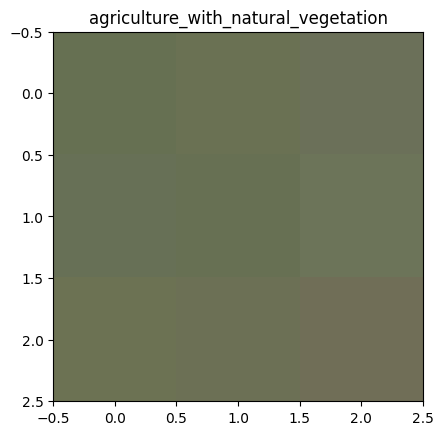

In [25]:
# Show a sample
sample = train_dataset[81]

arr = sample["image"].permute(2, 1, 0)
print(arr.shape)
rgb = arr[:, :, [2, 1, 0]]
rgb = np.clip(rgb, 0, 1)  # Ensure in [0, 1]
plt.imshow(rgb * 1.5)
plt.title(train_dataset.classes[sample["label"].item()])
plt.show()

In [26]:
remap_names, remap_indices = zip(
    *sorted(list(reverse_classnames.items()), key=lambda item: item[0])
)
assert list(remap_names) == train_dataset.classes
print(remap_indices)

(2, 3, 0, 4, 1, 6, 5, 7)


In [27]:
# Printing the class weights
class_weights = train_dataset.compute_class_weights()
pprint(class_weights)

{0: 0.00033344448149383126,
 1: 8.097428256785646e-06,
 2: 0.0002874389192296637,
 3: 0.00011242270938729624,
 4: 7.229612492770387e-05,
 5: 0.00020181634712411706,
 6: 7.091695624423799e-05,
 7: 0.0001212268153715602}


In [28]:
pprint(dict(zip(train_dataset.classes, class_weights.values())))

{'agriculture_with_natural_vegetation': 0.00033344448149383126,
 'coniferous_forest': 8.097428256785646e-06,
 'discontinuous_urban_fabric': 0.0002874389192296637,
 'mixed_forest': 0.00011242270938729624,
 'non_irrigated_arable_land': 7.229612492770387e-05,
 'peat_bogs': 0.00020181634712411706,
 'transitional_woodland_shrub': 7.091695624423799e-05,
 'water_bodies': 0.0001212268153715602}


### Data module class

Custom datamodule implementing the `NonGeoDataModule` interface from torchgeo. Implements weighted sampling to better handle the very uneven distribution of classes.

In [29]:
from torchgeo.datamodules import NonGeoDataModule


class CorineDataModule(NonGeoDataModule):
    @lru_cache
    def _get_sample_weights(self) -> torch.Tensor:

        class_weights = self.train_dataset.compute_class_weights()
        sample_weights = torch.tensor(
            [class_weights[sample["label"].item()] for sample in self.train_dataset]
        )

        return sample_weights

    def train_dataloader(self) -> DataLoader:
        sampling_strategy = cfg["data"].get("sampling_strategy", None)
        if not sampling_strategy == "weighted":
            print("Defaulting to random sampling in dataloader...")
            return super().train_dataloader()
        print("Using weighted sampler...")

        # sample_weights = torch.tensor([class_weights[sample["label"].item()] for sample in self.train_dataset])
        sample_weights = self._get_sample_weights()
        num_samples = len(sample_weights)
        assert num_samples == len(self.train_dataset)

        self.sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=num_samples,
            replacement=True,
        )

        return DataLoader(
            self.train_dataset,
            batch_size=cfg["training"]["batch_size"],
            shuffle=False,
            sampler=self.sampler,
            num_workers=2,
            pin_memory=True,
        )

In [30]:
# TODO: Is there a nice progress bar to use?
%timeit
dataset_folder = Path(DATA_ROOT / "processed")
corine_datamodule = CorineDataModule(
    CorineDataset,
    root=dataset_folder,
    batch_size=cfg["training"]["batch_size"],
    num_workers=2,
)

corine_datamodule.setup("fit")
corine_datamodule.train_dataloader().batch_size

Using weighted sampler...


32

In [31]:
sample_weights = corine_datamodule._get_sample_weights()
pprint(sample_weights.unique(return_counts=True))

(tensor([8.0974e-06, 7.0917e-05, 7.2296e-05, 1.1242e-04, 1.2123e-04, 2.0182e-04,
        2.8744e-04, 3.3344e-04]),
 tensor([123496,  14101,  13832,   8895,   8249,   4955,   3479,   2999]))


In [32]:
weights = corine_datamodule.train_dataset.compute_class_weights()
pprint(dict(zip(corine_datamodule.train_dataset.classes, weights.values())))

{'agriculture_with_natural_vegetation': 0.00033344448149383126,
 'coniferous_forest': 8.097428256785646e-06,
 'discontinuous_urban_fabric': 0.0002874389192296637,
 'mixed_forest': 0.00011242270938729624,
 'non_irrigated_arable_land': 7.229612492770387e-05,
 'peat_bogs': 0.00020181634712411706,
 'transitional_woodland_shrub': 7.091695624423799e-05,
 'water_bodies': 0.0001212268153715602}


### Trainer

In [33]:
# Callbacks for CNN
from lightning.pytorch.callbacks import Callback
import torch


class ClassDistributionCallback(Callback):
    def __init__(self, num_classes):
        super().__init__()
        self.num_classes = num_classes
        self.train_class_counts = []
        self.val_class_counts = []

    def on_train_batch_start(self, trainer, pl_module, batch, batch_idx):
        labels = batch["label"]
        counts = torch.bincount(labels, minlength=self.num_classes).cpu()
        self.train_class_counts.append(counts)

    def on_validation_batch_start(self, trainer, pl_module, batch, batch_idx, dataloader_idx=0):
        labels = batch["label"]
        counts = torch.bincount(labels, minlength=self.num_classes).cpu()
        self.val_class_counts.append(counts)

    def on_train_epoch_end(self, trainer, pl_module):
        if self.train_class_counts:
            train_dist = torch.stack(self.train_class_counts).float().mean(dim=0)
            trainer.train_class_dist = train_dist
            self.train_class_counts.clear()

    def on_validation_epoch_end(self, trainer, pl_module):
        if self.val_class_counts:
            val_dist = torch.stack(self.val_class_counts).float().mean(dim=0)
            trainer.val_class_dist = val_dist
            self.val_class_counts.clear()

class ValidationAccuracyCallback(Callback):
    def on_validation_epoch_end(self, trainer, pl_module):
        # Access validation accuracy from logged metrics
        val_acc = trainer.callback_metrics.get("val/Accuracy")
        # print(f"Validation Accuracy: {val_acc.item():.4f}")

        if val_acc is not None:
            print(f"Validation Accuracy: {val_acc.item():.4f}")

In [38]:
# New for CNN
classes = corine_datamodule.train_dataset.classes

pl.seed_everything(0)

checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath=DATA_ROOT / "training_logs",
    monitor="val_acc",
    mode="max",
    filename="{epoch}-{val_loss:.2f}-{val_acc:.2f}",
    save_weights_only=True,
)

trainer = pl.Trainer(
    accelerator="gpu",
    max_epochs=10,
    logger=False,
    log_every_n_steps=1,
    devices=1, # Using 4 GPUs
    callbacks=[
        checkpoint_callback,
        ClassDistributionCallback(num_classes=len(classes)),
        ValidationAccuracyCallback(),
        pl.callbacks.RichProgressBar(),
    ],
)

[rank: 0] Seed set to 0
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### TerraTorch task

In [39]:
# For CNN
import lightning.pytorch as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics


class ConvNet(pl.LightningModule):
    def __init__(
        self,
        num_classes,
        in_channels=4,
        patch_size=3,
        lr=3e-4,
        max_epochs=60,
        class_weights=None,
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])

        self.in_channels = in_channels
        self.patch_size = patch_size
        self.lr = lr
        self.max_epochs = max_epochs

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

        if class_weights is not None:
            self.register_buffer("class_weights", class_weights.float())
        else:
            self.class_weights = None

        self.val_acc = torchmetrics.classification.MulticlassAccuracy(num_classes=num_classes)
        self.test_acc = torchmetrics.classification.MulticlassAccuracy(num_classes=num_classes)

    def forward(self, x):
        x = x.float()
        return self.classifier(self.features(x))

    def _loss(self, logits, y):
        return F.cross_entropy(logits, y, weight=self.class_weights)

    def training_step(self, batch, batch_idx):
        x, y = batch["image"], batch["label"]
        y = y.long()

        logits = self(x)
        loss = self._loss(logits, y)

        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch["image"], batch["label"]
        y = y.long()

        logits = self(x)
        loss = self._loss(logits, y)
        preds = logits.argmax(dim=1)

        self.val_acc.update(preds, y)

        self.log("val_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))
        self.log("val_acc", self.val_acc, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))

    def test_step(self, batch, batch_idx):
        x, y = batch["image"], batch["label"]
        y = y.long()

        logits = self(x)
        loss = self._loss(logits, y)
        preds = logits.argmax(dim=1)

        self.test_acc.update(preds, y)

        self.log("test_loss", loss, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))
        self.log("test_acc", self.test_acc, prog_bar=True, on_step=False, on_epoch=True, batch_size=x.size(0))

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.max_epochs)
        return {"optimizer": opt, "lr_scheduler": sched}

In [40]:
# Task for CNN
task = ConvNet(
    num_classes=len(classes),
    in_channels=4,
    patch_size=3,
    lr=float(cfg["training"]["lr"]),
    max_epochs=int(cfg["training"]["epochs"]),
    class_weights=None,
)

In [41]:
# Fit the model
trainer.fit(model=task, datamodule=corine_datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential         │ 76.6 K │ train │     0 │
│ 1 │ classifier │ Sequential         │  8.8 K │ train │     0 │
│ 2 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ test_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 85.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

SLURM auto-requeueing enabled. Setting signal handlers.


Output()

/p/project1/training2600/christianson1/envs/ml_eo_course/lib/python3.12/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

Using weighted sampler...

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

`Trainer.fit` stopped: `max_epochs=10` reached.


In [42]:
print("Average train batch class distribution:")
for i, count in enumerate(trainer.train_class_dist):
    print(f"  {classes[i]}: {count.item():.2f}")

print("\nAverage val batch class distribution:")
for i, count in enumerate(trainer.val_class_dist):
    print(f"  {classes[i]}: {count.item():.2f}")

Average train batch class distribution:
  agriculture_with_natural_vegetation: 4.02
  coniferous_forest: 4.00
  discontinuous_urban_fabric: 4.00
  mixed_forest: 4.03
  non_irrigated_arable_land: 3.97
  peat_bogs: 3.97
  transitional_woodland_shrub: 3.98
  water_bodies: 4.01

Average val batch class distribution:
  agriculture_with_natural_vegetation: 0.53
  coniferous_forest: 21.92
  discontinuous_urban_fabric: 0.62
  mixed_forest: 1.58
  non_irrigated_arable_land: 2.45
  peat_bogs: 0.88
  transitional_woodland_shrub: 2.50
  water_bodies: 1.46


In [43]:
# Test the model
trainer.test(model=task, datamodule=corine_datamodule)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]
SLURM auto-requeueing enabled. Setting signal handlers.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.4625746011734009     │
│         test_loss         │     1.433943748474121     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.433943748474121, 'test_acc': 0.4625746011734009}]

### Prepare data for export to Evaluation notebook

In [44]:
# Collect predictions on test set
def collect_preds_targets(model, dataloader):
    model.eval()
    device = next(model.parameters()).device

    preds_all = []
    targets_all = []

    with torch.no_grad():
        for batch in dataloader:
            xb = batch["image"].to(device)
            yb = batch["label"]

            logits = model(xb)
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            targets = yb.cpu().numpy()

            preds_all.append(preds)
            targets_all.append(targets)

    y_pred = np.concatenate(preds_all).astype(np.int64)
    y_true = np.concatenate(targets_all).astype(np.int64)
    return y_true, y_pred

In [45]:
test_loader = corine_datamodule.test_dataloader()
y_true, y_pred = collect_preds_targets(task, test_loader)

class_names = np.array(classes, dtype=object)

print(y_true.shape, y_pred.shape)
print(class_names)

(9997,) (9997,)
['agriculture_with_natural_vegetation' 'coniferous_forest'
 'discontinuous_urban_fabric' 'mixed_forest' 'non_irrigated_arable_land'
 'peat_bogs' 'transitional_woodland_shrub' 'water_bodies']


In [46]:
from pathlib import Path

EVAL_PATH = Path(DATA_ROOT) / "evaluation" / "evaluation_outputs.npz"

np.savez(
    EVAL_PATH,
    y_true=y_true,
    y_pred=y_pred,
    class_names=class_names,
)

print(f"Saved evaluation data to: {EVAL_PATH}")

Saved evaluation data to: /p/scratch/training2600/team1/data/evaluation/evaluation_outputs.npz
